# Fleet Coverage: what share of the GB battery fleet do we actually analyse?

**Research premise.** Every fleet-level result in this project is computed on the 23 sites of
`fleet.registry`. That registry is honest about being a curated cross-section, but a
cross-section supports a general claim only as far as its representativeness is *measured*.
Until it is, "the fleet discharges into stress" means "these 23 sites do", and a reviewer is
right to discount it.

**The question, stated so it can be answered.** What percentage of GB operational battery
MW and MWh in July 2026 is represented by the 23 sites? Everything else in this notebook is
secondary to that number.

**Why it takes work.** Nobody publishes the list. Elexon's BM Unit reference — the only
per-unit feed this project can settle against — labels no unit as a battery: 2,470 of 3,055
units carry no fuel type at all, and not one row says "battery". So the denominator has to be
*reconstructed* from what several public registers agree on, which is what `fleet.census`
does and what section 1 audits before any percentage is quoted.

**Method.** The four tiers of the coverage brief, in order:

1. **Coverage assessment** — every known battery, in the registry or not, and *why* not.
2. **Representativeness** — coverage by site count, by MW, by MWh.
3. **Characterising the gap** — how included sites differ from excluded ones.
4. **A persistent asset ID** — so the answer survives owner, name and BMU changes.

**Scope, stated once.** The denominator is *BM-registered* batteries. Assets traded behind an
aggregator, VLP or supplier portfolio are physically real but have no per-unit Elexon feed, so
they can be neither dispatch-analysed nor counted here. Every percentage below is a share of
the BM-registered fleet, not of GB storage — and section 5 sizes what that leaves out.

In [1]:
%matplotlib inline

import sys
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd

REPO_ROOT = Path("..").resolve()
sys.path.insert(0, str(REPO_ROOT))

from fleet import ancillary, census, coverage
from fleet.registry import FLEET

warnings.filterwarnings("ignore")

plt.rcParams.update({
    "figure.dpi": 120,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "grid.linestyle": "--",
})

# Same design system as notebooks 04 and 05. The two-class split used throughout
# this notebook is "covered by the registry" against "the gap" — both are real
# quantities, so both get a real colour rather than one fading into grey.
C = {
    "ink":       "#0b0b0b",
    "covered":   "#2a78d6",
    "gap":       "#e34948",
    "discharge": "#1baf7a",
    "mid":       "#c98500",
    "ghost":     "#c3c2b7",
}

# The window the rest of the project analyses. The census itself is a July-2026
# snapshot — a registry of what exists now — but the revenue section in part 7
# reaches back across the whole analysis window.
import datetime as dt

ANALYSIS_START = dt.date(2023, 10, 1)
ANALYSIS_END = dt.date(2026, 8, 19)

## 1. Building the census — and auditing it before trusting it

Five public sources, each cached once per day. Elexon's BM Unit reference supplies the
population to classify; the NESO Capacity Market register supplies explicit `Storage`
technology *with duration*, which is the only free source that yields **MWh** rather than MW
alone; the TEC and Embedded connection registers supply built storage projects and their
connection dates; the response-auction results supply an explicit `Batteries` technology type
per participant.

**The identifying rule.** Four necessary conditions, all read off Elexon's own reference data:
the unit is physical (not a supplier portfolio or interconnector), carries no conflicting fuel
label, declares both import and export capability, and declares them **symmetrically**.

That last condition is what makes the rule precise rather than merely plausible. A battery's
charge and discharge ratings are near-symmetric by construction. A generator with a site load
looks bidirectional but is nowhere near symmetric. The cell below plots the two populations
so the separation can be seen rather than asserted.

In [2]:
units = census.battery_bmus()

known = units[units["sig_registry"]]
print(f"BMU population              {len(units):,}")
print(f"units with no fuel type     {int(units['fuelType'].isna().sum()):,}")
print(f"classified as batteries     {int(units['is_battery'].sum()):,}")
print()
print("Recall check — the curated registry is ground truth the rule never sees:")
print(f"  registry BM Units          {len(known)}")
print(f"  recovered by the rule      {int((known['is_physical'] & known['fuel_permits_battery'] & known['is_bidirectional'] & known['is_symmetric']).sum())}")
print()
print("Confidence of the classified population:")
print(units.loc[units["is_battery"], "confidence"].value_counts().to_string())

BMU population              3,055
units with no fuel type     2,470
classified as batteries     127

Recall check — the curated registry is ground truth the rule never sees:
  registry BM Units          47
  recovered by the rule      47

Confidence of the classified population:
confidence
corroborated      77
registry          47
signature_only     3


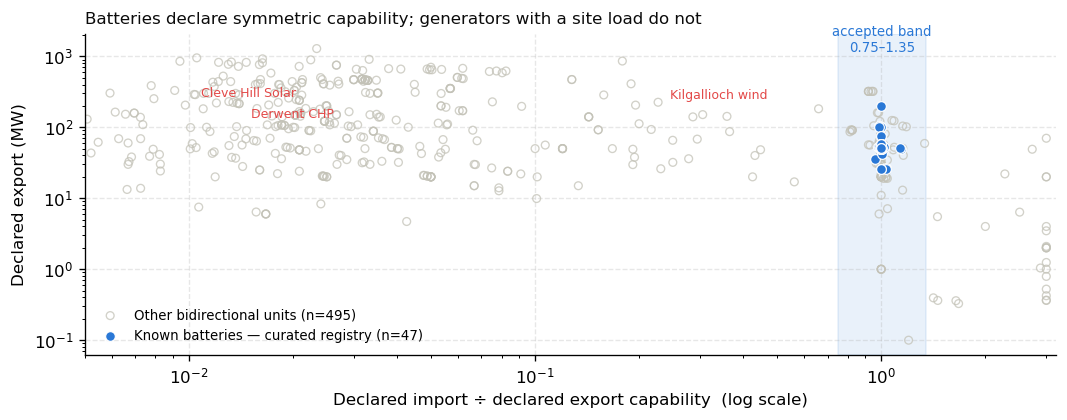

In [3]:
# Figure 1 — the symmetry test, and why it separates cleanly.
bidir = units[units["is_bidirectional"] & units["is_physical"]].copy()
bidir["ratio"] = bidir["capability_ratio"].clip(upper=3.0)

fig, ax = plt.subplots(figsize=(9, 3.6))
lo, hi = census.SYMMETRY_BAND
ax.axvspan(lo, hi, color=C["covered"], alpha=0.10, zorder=0)

rest = bidir[~bidir["sig_registry"]]
ax.scatter(rest["ratio"], rest["generationCapacity"], s=22, facecolor="none",
           edgecolor=C["ghost"], linewidth=0.8, alpha=0.75,
           label=f"Other bidirectional units (n={len(rest)})", zorder=2)
ax.scatter(known["capability_ratio"].clip(upper=3.0), known["generationCapacity"], s=34,
           color=C["covered"], edgecolor="white", linewidth=0.7,
           label=f"Known batteries — curated registry (n={len(known)})", zorder=3)

# Offsets are set individually: these three sit close together and default
# placement overlaps them.
for label, x, y, off in [("Cleve Hill Solar", 0.010, 205.0, (7, 5)),
                         ("Derwent CHP", 0.014, 218.0, (7, -9)),
                         ("Kilgallioch wind", 0.227, 225.0, (7, 2))]:
    ax.annotate(label, (x, y), fontsize=7.5, color=C["gap"],
                xytext=off, textcoords="offset points")

ax.set_xscale("log")
# Log on both axes: the background population spans 1-1200 MW, and on a linear
# scale the batteries all pile into the bottom eighth of the panel.
ax.set_yscale("log")
ax.set_xlim(0.005, 3.2)
ax.set_xlabel("Declared import ÷ declared export capability  (log scale)")
ax.set_ylabel("Declared export (MW)")
ax.set_title("Batteries declare symmetric capability; generators with a site load do not",
             fontsize=10, loc="left", color=C["ink"])
ax.annotate(f"accepted band\n{lo}–{hi}", (np.sqrt(lo * hi), ax.get_ylim()[1] * 0.55),
            ha="center", fontsize=8, color=C["covered"])
ax.legend(frameon=False, fontsize=8, loc="lower left")
plt.tight_layout()
plt.show()

## 2. Tier 1 — the coverage table

One row per known battery site, whether the registry contains it, and if not, why. The reason
carries more weight than the count. A site missing because it is 12 MW is a scope decision the
registry states up front; a site missing because nobody added it is the real gap, and it is
that second number a reviewer should be handed.

In [4]:
table = coverage.coverage_table()

print(f"census sites: {len(table)}   BM Units: {int(table['n_bmus'].sum())}   "
      f"declared MW: {table['declared_export_mw'].sum():,.0f}\n")
print(table["missing_reason"].fillna("in the registry").value_counts().to_string())
print()
print(f"energy capacity known for {int(table['capacity_mwh'].notna().sum())} of {len(table)} sites",
      dict(table["mwh_source"].value_counts()))

census sites: 90   BM Units: 127   declared MW: 6,348

missing_reason
not curated         47
in the registry     23
below size floor    20

energy capacity known for 42 of 90 sites {'registry': np.int64(23), 'capacity_market': np.int64(19)}


In [5]:
# The sites the registry omits that meet its own stated inclusion criteria —
# the shortlist for closing the gap, largest first.
gap = table[table["missing_reason"] == "not curated"]
cols = ["site_name", "lead_party", "declared_export_mw", "n_bmus", "connection_level", "confidence"]
print(f"{len(gap)} uncurated sites above the registry's own {coverage.REGISTRY_SIZE_FLOOR_MW:.0f} MW floor, "
      f"totalling {gap['declared_export_mw'].sum():,.0f} MW\n")
gap[cols].head(20).to_string(index=False)

47 uncurated sites above the registry's own 34 MW floor, totalling 3,133 MW



'                    site_name                   lead_party  declared_export_mw  n_bmus connection_level     confidence\n      Monk Fryston BESS BMU-1 SSE Battery Monk Fryston Ltd             320.000       4     Transmission   corroborated\n                    T_THURB-1     THURROCK STORAGE LIMITED             300.000       3     Transmission   corroborated\n                   Iron Acton                 HD000ACT Ltd             121.000       1     Transmission   corroborated\n               Lakeside  BESS  Lakeside Energy Storage Ltd             105.000       1     Transmission   corroborated\n               Brentwood BESS EDF Energy Customers Limited             104.000       2     Distribution   corroborated\n                Berkeley BESS EDF Energy Customers Limited             104.000       2     Distribution   corroborated\n           KXP Immingham BESS            KXP Immingham Ltd              80.844       1     Distribution   corroborated\n                   ENRON MANX       Sma

## 3. Tier 2 — representativeness

Three bases, because they disagree and the disagreement is informative.

**Site count flatters nothing here** — it is the *lowest* of the three, because the registry
deliberately picked large assets. **MW is the headline**: it is what fleet response, headroom
and availability are all measured in. **MWh is the most useful and the least available** —
duration is published only through Capacity Market agreements, and those link to a BM Unit for
a minority of sites, so it is reported over the known subset and labelled as a ceiling rather
than extrapolated across the rest.

In [6]:
stats = coverage.representativeness(table)
stats

,registry,census,coverage_pct,note
basis,,,,
sites,23.0,90.0,25.6,every BM-registered battery site
MW (declared export),2890.5,6347.5,45.5,the headline figure
MWh (where known),5179.0,6391.0,81.0,duration known for 23/23 registry vs 19/67 oth...


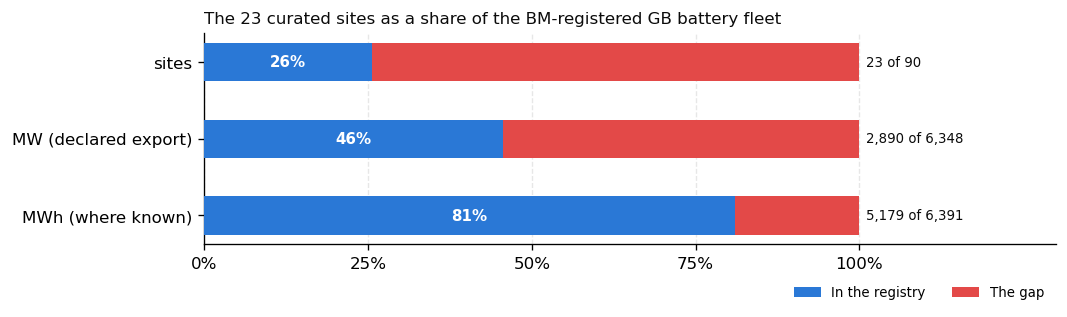

In [7]:
# Figure 2 — coverage on each basis, with the gap drawn as a real quantity.
fig, ax = plt.subplots(figsize=(9, 2.9))

bases = list(stats.index)
y = np.arange(len(bases))
covered = stats["registry"].to_numpy()
total = stats["census"].to_numpy()
gap_v = total - covered

# Each basis is on its own scale (sites, MW, MWh), so bars are drawn as a share
# of their own total — the absolute figures are direct-labelled instead.
share = covered / total
ax.barh(y, share, height=0.5, color=C["covered"], label="In the registry", zorder=3)
ax.barh(y, 1 - share, left=share, height=0.5, color=C["gap"],
        label="The gap", zorder=3)

for i, (base, s) in enumerate(zip(bases, share)):
    ax.text(s / 2, i, f"{s:.0%}", ha="center", va="center", color="white",
            fontsize=9, fontweight="bold", zorder=4)
    ax.text(1.01, i, f"{covered[i]:,.0f} of {total[i]:,.0f}", va="center",
            fontsize=8, color=C["ink"])

ax.set_yticks(y, bases)
ax.set_xlim(0, 1.30)
ax.xaxis.set_major_formatter(mticker.PercentFormatter(1.0))
ax.set_xticks([0, 0.25, 0.5, 0.75, 1.0])
ax.invert_yaxis()
ax.grid(axis="y", visible=False)
ax.set_title("The 23 curated sites as a share of the BM-registered GB battery fleet",
             fontsize=10, loc="left", color=C["ink"])
ax.legend(frameon=False, fontsize=8, ncol=2, loc="lower right", bbox_to_anchor=(1.0, -0.32))
plt.tight_layout()
plt.show()

## 4. Tier 3 — characterising the gap

A percentage without a direction invites exactly the criticism this notebook exists to answer.
The comparisons below say *which* assets the registry over- and under-represents, which is what
turns "45% of MW" into a statement about which results generalise and which do not.

In [8]:
gaps = coverage.gap_characterisation(table)
gaps["size_band"]

,sites,sites_in_registry,mw,mw_in_registry,coverage_pct
size_band,,,,,
200+ MW,7,5,2083.8,1463.8,70.2
50-100 MW,32,9,1890.7,609.0,32.2
20-50 MW,34,4,1251.2,176.0,14.1
100-200 MW,9,5,1075.6,641.6,59.7
0-20 MW,8,0,46.2,0.0,0.0


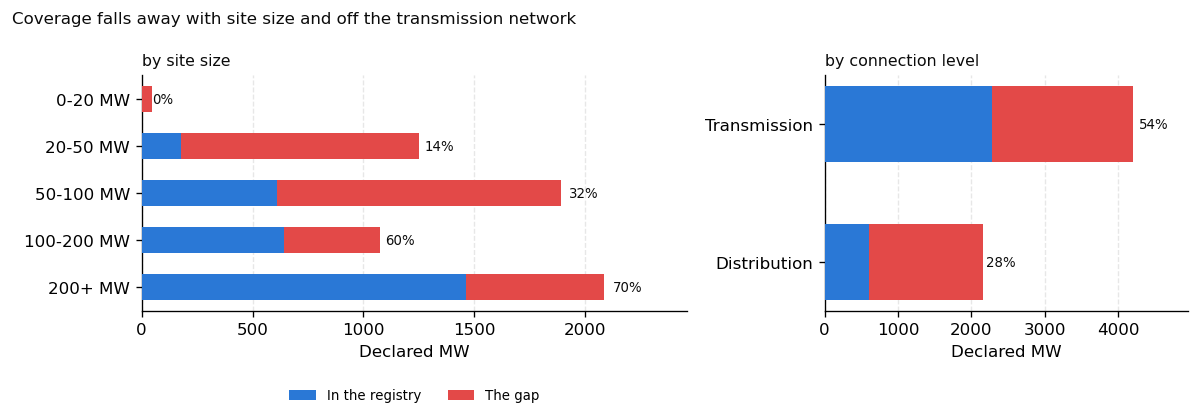

In [9]:
# Figure 3 — where the missing MW actually sits.
by_size = gaps["size_band"].reindex(
    [f"{lo}-{hi} MW" if hi < 10_000 else f"{lo}+ MW" for lo, hi in coverage.SIZE_BANDS]
).dropna(how="all")
by_conn = gaps["connection_level"]

fig, axes = plt.subplots(1, 2, figsize=(10, 3.8), gridspec_kw={"width_ratios": [3, 2]})

for ax, frame, title in (
    (axes[0], by_size, "by site size"),
    (axes[1], by_conn, "by connection level"),
):
    y = np.arange(len(frame))
    cov_mw = frame["mw_in_registry"].to_numpy()
    gap_mw = (frame["mw"] - frame["mw_in_registry"]).to_numpy()
    ax.barh(y, cov_mw, height=0.55, color=C["covered"], label="In the registry", zorder=3)
    ax.barh(y, gap_mw, left=cov_mw, height=0.55, color=C["gap"], label="The gap", zorder=3)
    for i, pct in enumerate(frame["coverage_pct"]):
        ax.text(frame["mw"].iloc[i] * 1.02, i, f"{pct:.0f}%", va="center",
                fontsize=8, color=C["ink"])
    ax.set_yticks(y, frame.index)
    ax.invert_yaxis()
    ax.grid(axis="y", visible=False)
    ax.set_xlabel("Declared MW")
    ax.set_xlim(0, frame["mw"].max() * 1.18)
    ax.set_title(title, fontsize=9.5, loc="left", color=C["ink"])

# Below the axes: inside the panel the legend lands on the 200+ MW bar.
axes[0].legend(frameon=False, fontsize=8, ncol=2, loc="upper center",
               bbox_to_anchor=(0.5, -0.28))
fig.suptitle("Coverage falls away with site size and off the transmission network",
             fontsize=10, x=0.005, ha="left", color=C["ink"])
plt.tight_layout()
plt.show()

In [10]:
# Owners the registry misses entirely, ranked by the MW they operate.
owners = gaps["owner"]
missed = owners[owners["mw_in_registry"] == 0].sort_values("mw", ascending=False)
print(f"{len(missed)} operators are absent from the registry, "
      f"together running {missed['mw'].sum():,.0f} MW across {int(missed['sites'].sum())} sites\n")
missed.head(12)[["sites", "mw"]].to_string()

20 operators are absent from the registry, together running 1,582 MW across 25 sites



'                              sites     mw\nlead_party                                \nSSE Battery Monk Fryston Ltd      1  320.0\nTHURROCK STORAGE LIMITED          1  300.0\nHD000ACT Ltd                      1  121.0\nLakeside Energy Storage Ltd       1  105.0\nKXP Immingham Ltd                 1   80.8\nConrad Energy (Trading) Ltd       4   72.7\nSmartestenergy Limited            1   63.7\nWest Burton B Limited             1   62.0\nHD144WHI Ltd                      1   58.0\nHD143OCK Ltd                      1   58.0\nHD777FRY Ltd                      1   57.0\nHD888CAP Ltd                      1   57.0'

## 5. Tier 4 — a persistent asset ID, and what stays outside it

Sites change owner, change name and change BM Unit registration. Keyed on any of those, one
asset silently becomes two across a multi-year window — which is precisely the window this
project analyses. `fleet.census` keys on the National Grid BMU root, which is tied to the
physical connection point rather than to the commercial arrangement around it, so a
re-contracted site stays one row. Roots that genuinely moved are stitched by an explicit alias
map rather than by fuzzy matching.

The cell below also sizes the honest limit of the whole exercise: the aggregator and supplier
portfolio units. They are real routes to market for real batteries, but they are portfolios,
not sites — no per-unit Physical Notification, no per-site cashflow — so they can be counted
as an unknown, never analysed.

In [11]:
multi = table[table["n_bmus"] > 1]
print(f"{len(multi)} of {len(table)} sites span more than one BM Unit "
      f"({int(multi['n_bmus'].sum())} units in total).")
print("Without a persistent asset ID each of those would count as several assets.\n")

# The portfolio tier: bidirectional supplier/VLP units, outside the site denominator.
portfolios = units[
    (units["bmUnitType"] == "S")
    & units["is_bidirectional"]
    & units["is_symmetric"]
]
print(f"Supplier/VLP portfolio units with a battery-like signature: {len(portfolios)}, "
      f"{portfolios['generationCapacity'].sum():,.0f} MW declared.")
print("Counted as an unknown above the census, never as sites.")

18 of 90 sites span more than one BM Unit (55 units in total).
Without a persistent asset ID each of those would count as several assets.

Supplier/VLP portfolio units with a battery-like signature: 72, 2,220 MW declared.
Counted as an unknown above the census, never as sites.


## 6. Robustness — does the answer depend on the threshold?

The symmetry band is the only tuned number in the identifying rule, so the coverage figure is
only as good as its insensitivity to it. If the answer moved materially between a tight band
and a loose one, it would be an artefact of the choice rather than a measurement.

In [12]:
base = units["is_physical"] & units["fuel_permits_battery"] & units["is_bidirectional"]
bands = [(0.90, 1.20), (0.85, 1.25), (0.80, 1.30), (0.75, 1.35), (0.70, 1.50), (0.60, 1.70), (0.50, 2.00)]

rows = []
registry_mw = table.loc[table["in_registry"], "declared_export_mw"].sum()
for lo, hi in bands:
    sel = base & units["capability_ratio"].between(lo, hi)
    census_mw = units.loc[sel, "generationCapacity"].sum()
    rows.append({
        "band": f"[{lo:.2f}, {hi:.2f}]",
        "units": int(sel.sum()),
        "census_mw": round(census_mw, 0),
        "coverage_pct": round(100 * registry_mw / census_mw, 1),
        "registry_recall": f"{int((sel & units['sig_registry']).sum())}/{len(known)}",
    })
sensitivity = pd.DataFrame(rows).set_index("band")
sensitivity

,units,census_mw,coverage_pct,registry_recall
band,,,,
"[0.90, 1.20]",126,6288.0,46.0,47/47
"[0.85, 1.25]",126,6288.0,46.0,47/47
"[0.80, 1.30]",126,6288.0,46.0,47/47
"[0.75, 1.35]",127,6348.0,45.5,47/47
"[0.70, 1.50]",130,6354.0,45.5,47/47
"[0.60, 1.70]",132,6354.0,45.5,47/47
"[0.50, 2.00]",133,6358.0,45.5,47/47


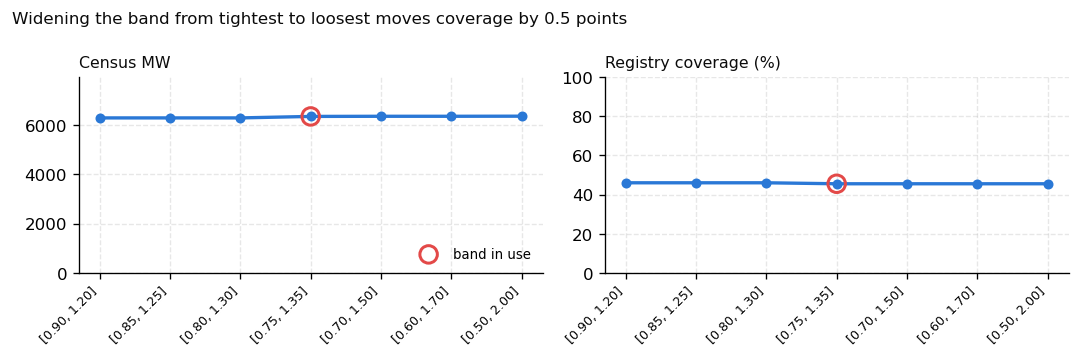

In [13]:
# Figure 4 — two panels, never two y-axes on one.
fig, axes = plt.subplots(1, 2, figsize=(9, 3.0), sharex=True)
x = np.arange(len(sensitivity))
selected = [i for i, b in enumerate(sensitivity.index)
            if b == f"[{census.SYMMETRY_BAND[0]:.2f}, {census.SYMMETRY_BAND[1]:.2f}]"]

# Both panels start at zero. The claim being made is that the result barely
# moves, and a truncated axis would manufacture a cliff out of a 1% change —
# arguing against the very point of the figure.
for i, (ax, column, label, top) in enumerate((
    (axes[0], "census_mw", "Census MW", sensitivity["census_mw"].max() * 1.25),
    (axes[1], "coverage_pct", "Registry coverage (%)", 100.0),
)):
    ax.plot(x, sensitivity[column], color=C["covered"], lw=2, marker="o", ms=5, zorder=3)
    if selected:
        ax.scatter(selected, sensitivity[column].iloc[selected], s=110, facecolor="none",
                   edgecolor=C["gap"], lw=1.8, zorder=4, label="band in use")
    ax.set_ylim(0, top)
    ax.set_xticks(x, sensitivity.index, rotation=45, ha="right", fontsize=7.5)
    ax.set_title(label, fontsize=9.5, loc="left", color=C["ink"])

axes[0].legend(frameon=False, fontsize=8, loc="lower right")
spread = sensitivity["coverage_pct"].max() - sensitivity["coverage_pct"].min()
fig.suptitle(f"Widening the band from tightest to loosest moves coverage by {spread:.1f} points",
             fontsize=10, x=0.005, ha="left", color=C["ink"])
plt.tight_layout()
plt.show()

## 7. The revenue stack we can and cannot see

Coverage of *assets* is one half of the question; coverage of *revenue* is the other. The
project prices two streams — the wholesale position at MID and Balancing Mechanism cashflows
through `EBOCF` — and for a GB battery that is knowingly incomplete. Frequency response and
reserve have historically been the dominant earner, so a site that looks unprofitable on
wholesale plus BM alone may simply be earning somewhere the analysis was not looking.

`fleet.ancillary` adds that third stream at site level. It joins without any fuzzy matching:
NESO's auction results name the winning unit by its National Grid BM Unit name — `KILSB-5`,
`CLAYB-1`, `THURB-3` — which is exactly the key `fleet.census` already uses.

**The history is fragmented, and that is the headline caveat.** NESO replaced its auction
platform twice across this window and published per-unit results under three schemas with real
gaps between them. Two traps follow, and the cells below refuse both rather than paper over
them: a month with no data is *not* a month of zero revenue, and — more subtly — two months
that both have data are not comparable if they cover different **services**.

In [14]:
anc_cov = ancillary.coverage_by_month(ANALYSIS_START, ANALYSIS_END)
print(f"months with any per-unit ancillary data: {int(anc_cov['covered'].sum())} of {len(anc_cov)} "
      f"({100 * anc_cov['covered'].mean():.0f}%)\n")

gaps = anc_cov[~anc_cov["covered"]]
print("Months NESO published no per-unit results for — these are gaps, not zeros:")
print("  " + ", ".join(gaps.index) if len(gaps) else "  none")

months with any per-unit ancillary data: 28 of 35 (80%)

Months NESO published no per-unit results for — these are gaps, not zeros:
  2023-12, 2024-01, 2024-02, 2025-11, 2025-12, 2026-01, 2026-02


In [15]:
# The only unit of legitimate comparison: contiguous months sharing a service set.
windows = ancillary.comparable_windows(anc_cov)
windows.assign(gbp_m=(windows["revenue_gbp"] / 1e6).round(2)).drop(columns="revenue_gbp")

,first_month,last_month,months,services,era,gbp_m
0,2023-10,2023-11,2,"DCH, DCL, DMH, DML, DRH, DRL",DC/DR/DM (2021-09 → 2023-11),8.23
1,2024-03,2025-10,20,Balancing Reserve,Balancing Reserve (2024-03 → 2025-10),6.01
2,2026-03,2026-08,6,"Balancing Reserve, Quick Reserve, Response, Sl...",EAC Response/Reserve (2026-03 → present),52.87


The middle window is the trap made concrete. It looks complete — twenty consecutive months,
almost every day present — but it carries **only Balancing Reserve**, a minor product. Reading
its revenue against the DC/DR/DM window either side would show a collapse of over 90% that is
entirely an artefact of which auction NESO happened to publish per-unit. Any trend line drawn
across these three windows measures NESO's publishing history, not the market.

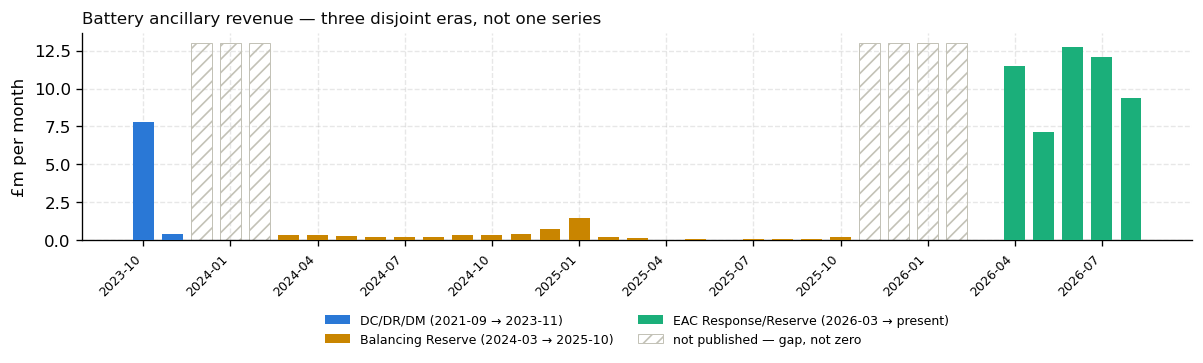

In [16]:
# Figure 5 — monthly ancillary revenue, with the gaps left as gaps.
monthly = anc_cov.copy()
monthly["gbp_m"] = monthly["revenue_gbp"] / 1e6

fig, ax = plt.subplots(figsize=(10, 3.4))
x = np.arange(len(monthly))

# One colour per comparable window, so the eye cannot join them into a trend.
era_order = [e for e in monthly["era"].dropna().unique()]
era_colour = dict(zip(era_order, [C["covered"], C["mid"], C["discharge"]]))
for era in era_order:
    mask = monthly["era"] == era
    ax.bar(x[mask.to_numpy()], monthly.loc[mask, "gbp_m"], width=0.72,
           color=era_colour[era], label=era, zorder=3)

# Gap months are drawn as hatched ground, never as a zero bar.
gap_mask = (~monthly["covered"]).to_numpy()
if gap_mask.any():
    ax.bar(x[gap_mask], np.full(gap_mask.sum(), monthly["gbp_m"].max() * 1.02),
           width=0.72, color="none", edgecolor=C["ghost"], hatch="///",
           linewidth=0.6, label="not published — gap, not zero", zorder=2)

ax.set_xticks(x[::3], monthly.index[::3], rotation=45, ha="right", fontsize=7.5)
ax.set_ylabel("£m per month")
ax.set_title("Battery ancillary revenue — three disjoint eras, not one series",
             fontsize=10, loc="left", color=C["ink"])
ax.legend(frameon=False, fontsize=7.5, loc="upper center", bbox_to_anchor=(0.5, -0.30), ncol=2)
plt.tight_layout()
plt.show()

### How much of that revenue reaches a site

The same aggregator problem that limits the asset census limits the revenue view. A unit
trading as `AG-GBL0EN` or `HAB-15` is a portfolio, not a site — its earnings are real but
cannot be attributed to an asset without inventing a mapping. They are reported here rather
than dropped, so the fleet total and the sum of its named sites never silently disagree.

In [17]:
attribution = ancillary.unmatched_summary()
attribution.assign(
    attributed_gbp_m=(attribution["attributed_gbp"] / 1e6).round(2),
    unattributed_gbp_m=(attribution["unattributed_gbp"] / 1e6).round(2),
)[["attributed_gbp_m", "unattributed_gbp_m", "attributed_pct"]]

,attributed_gbp_m,unattributed_gbp_m,attributed_pct
era,,,
Balancing Reserve (2024-03 → 2025-10),5.67,0.34,94.4
DC/DR/DM (2021-09 → 2023-11),122.10,81.61,59.9
EAC Response/Reserve (2026-03 → present),25.56,27.30,48.4


In [18]:
# Ancillary earnings by site over the most recent comparable window only — the
# one carrying the full service stack. Earlier windows are a different product
# mix and must not be pooled with it.
recent = windows.iloc[-1]
window_start = pd.Period(recent["first_month"]).start_time.date()

stack = ancillary.with_census()
stack = stack[stack["date"] >= window_start]

# `unit_class` says what each winning unit actually is. Only one of the four
# is a physical site, and it is not the largest.
by_class = (stack.groupby("unit_class")["revenue_gbp"].sum() / 1e6).round(2)
print(f"Ancillary earnings, {recent['first_month']} → {recent['last_month']}")
print(f"services: {recent['services']}")
print(f"total £{stack['revenue_gbp'].sum() / 1e6:.1f}m\n")
print((by_class.sort_values(ascending=False).to_frame("£m")
       .assign(share=(100 * by_class / by_class.sum()).round(1))).to_string())

Ancillary earnings, 2026-03 → 2026-08
services: Balancing Reserve, Quick Reserve, Response, Slow Reserve
total £52.9m

                         £m  share
unit_class                        
aggregator portfolio  27.30   51.6
census site           13.67   25.9
VLP / supplier unit    8.82   16.7
unknown                3.08    5.8


In [19]:
# The sites themselves, within the only class that is one.
sites_only = stack[stack["unit_class"] == "census site"]
by_site = (sites_only.groupby(["site_name", "in_registry"], dropna=False)["revenue_gbp"]
                     .sum().sort_values(ascending=False).reset_index())
by_site["gbp_k"] = (by_site["revenue_gbp"] / 1e3).round(0)
print(f"{len(by_site)} census sites earned ancillary revenue in this window; "
      f"{int(by_site['in_registry'].sum())} of them are in the curated registry\n")
by_site.head(15)[["site_name", "in_registry", "gbp_k"]].to_string(index=False)

65 census sites earned ancillary revenue in this window; 17 of them are in the curated registry



'                  site_name  in_registry  gbp_k\n                  T_PINFB-1         True 1320.0\n  Richborough Energy Park 1         True 1132.0\n                  T_THURB-1        False  797.0\n   Burwell Weirs Drove BESS         True  781.0\n                Wishaw BESS         True  709.0\nPillswood 1 Battery Storage         True  697.0\n         Whitelee 1 Battery         True  643.0\n             Roosecote BESS         True  619.0\n             Brentwood BESS        False  606.0\n    Tollgate Energy Storage        False  575.0\n           Newton wood BESS        False  528.0\n   Nursling Battery Storage        False  524.0\n            Brook Farm BESS        False  450.0\n  Hunningley Stairfoot BESS        False  450.0\n              Berkeley BESS        False  407.0'

Only about a quarter of recent battery ancillary revenue lands on a physical BM-registered
site. Aggregator portfolios take roughly half, and VLP or supplier routes most of the rest.
This is the same finding as the asset census reached from the other direction: the part of the
GB battery fleet that can be analysed per site is a minority of the whole, and the aggregator
tier — invisible to every per-unit feed this project can reach — is where a large share of the
activity and the earnings actually sit.

## 8. The claim

The sentence below is what every fleet-level result in this project should be quoted beside.
It is deliberately less comfortable than the number one would hope for, and it is the one that
survives scrutiny.

In [20]:
print(coverage.headline_claim(table))

The registry's 23 sites capture 45.5% of GB BM-registered operational battery MW (90 sites in total), and under-represent 0-20 MW and 20-50 MW assets. Batteries traded behind aggregator, VLP or supplier portfolios have no per-unit settlement data and are outside this denominator entirely.


### What this changes

**What still generalises.** Results about large, transmission-connected, BM-traded batteries —
the majority of GB battery MW and nearly all of its BM activity. Coverage there is 70% of
200 MW+ MW and 54% of transmission-connected MW, which is enough to speak about the segment.

**What does not.** Any statement about "the GB battery fleet" without qualification. Coverage
of 20–50 MW assets is 14% and of sub-20 MW assets is zero, so nothing here describes the small
distribution-connected tail — where trading behaviour, revenue stack and duration all differ
most from the large sites.

**The cheapest way to improve it.** The uncurated sites in section 2 are already BM-registered
with their own BM Units, so they need no new data source and no new code — only registry
entries. Adding the largest of them closes most of the MW gap; adding the 20–50 MW band closes
the bias that matters most for generalisation.